In [17]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations

fig_DIR = "./figures/"
%matplotlib widget

In [2]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe()
param = spme.param

In [3]:
# Cn
C_n_init = 4.19
# Cp
C_p_init = 3.85
# x0 or x100 depending on starting at 0 SOC or 1 SOC
x_init = 0.005
# y0 or y100 depending on starting at 0 SOC or 1 SOC
y_init = 0.92

In [4]:
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))

In [5]:
cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

In [6]:
# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
    },
    check_already_exists=False,
)

In [7]:
c_rate_d = "C/3"
c_rate_c = "C/3"


experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+" until 3V",
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/20")
    ] ,
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

sim_0 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve()

t_1 = sol_0["Time [s]"].entries
I_1 = sol_0["Current [A]"].entries
Q_1 = sol_0['Discharge capacity [A.h]'].entries
Vt_1 = sol_0["Terminal voltage [V]"].entries

CasADi - 2023-10-02 09:46:32 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


In [61]:
parameter_values.search("layers")

No results for search using 'layers'. Best matches are []


In [9]:
# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode porosity": 0.2,
        "Positive electrode porosity": 0.3,
        "Separator porosity": 0.48*0.8,
    },
    check_already_exists=False,
)

sim_1 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_1 = sim_1.solve()

t_1 = sol_1["Time [s]"].entries
I_1 = sol_1["Current [A]"].entries
Q_1 = sol_1['Discharge capacity [A.h]'].entries
Vt_1 = sol_1["Terminal voltage [V]"].entries

In [45]:
spme.variables.search("inactive")

No results for search using 'inactive'. Best matches are []


In [41]:
x = sol_0["x [m]"].entries
x_n = sol_0["x_n [m]"].entries
c_e_0 = sol_0["Electrolyte concentration [mol.m-3]"].entries
c_e_1 = sol_1["Electrolyte concentration [mol.m-3]"].entries
phi_e_0 = sol_0["Electrolyte potential [V]"].entries
phi_e_1 = sol_1["Electrolyte potential [V]"].entries
phi_n_0 = sol_0["Negative electrode reaction overpotential [V]"].entries
phi_n_1 = sol_1["Negative electrode reaction overpotential [V]"].entries


In [19]:
sim_des = "only_sep"

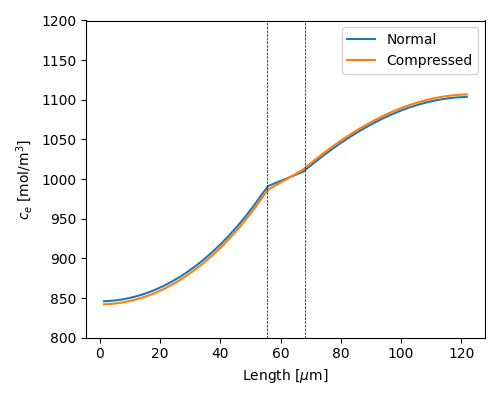

In [29]:
fig = plt.figure(figsize=[5,4])
ax1 = plt.subplot(1,1,1)
ax1.plot(x[:,100]*1e6,c_e_0[:,100])
ax1.plot(x[:,100]*1e6,c_e_1[:,100])
ax1.axvline(x=55.6,color='k', linestyle='--',linewidth=0.5)
ax1.axvline(x=55.6+12.5,color='k', linestyle='--',linewidth=0.5)
ax1.set_xlabel('Length [$\mu$m]')
ax1.set_ylim([800,1200])
ax1.set_ylabel('$c_e$ [mol/m$^3$]')
ax1.legend(['Normal', 'Compressed'])
fig.tight_layout()
fig.savefig(fig_DIR +'electrolyte_conc_' +sim_des +'.png')

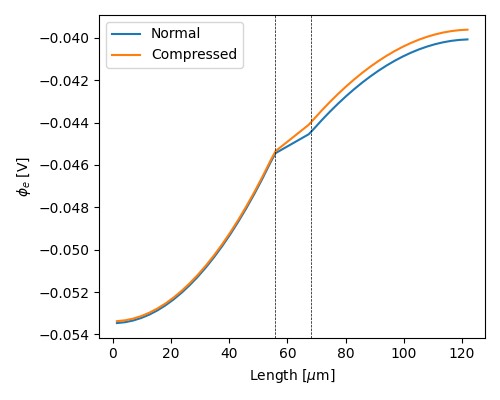

In [30]:
fig = plt.figure(figsize=[5,4])
ax1 = plt.subplot(1,1,1)
ax1.plot(x[:,100]*1e6,phi_e_0[:,100])
ax1.plot(x[:,100]*1e6,phi_e_1[:,100])
ax1.axvline(x=55.6,color='k', linestyle='--',linewidth=0.5)
ax1.axvline(x=55.6+12.5,color='k', linestyle='--',linewidth=0.5)
ax1.set_xlabel('Length [$\mu$m]')
# ax1.set_ylim([-0.2,0])
ax1.set_ylabel('$\phi_e$ [V]')
ax1.legend(['Normal', 'Compressed'])
fig.tight_layout()
fig.savefig(fig_DIR +'electrolyte_pot_'+sim_des+'.png')

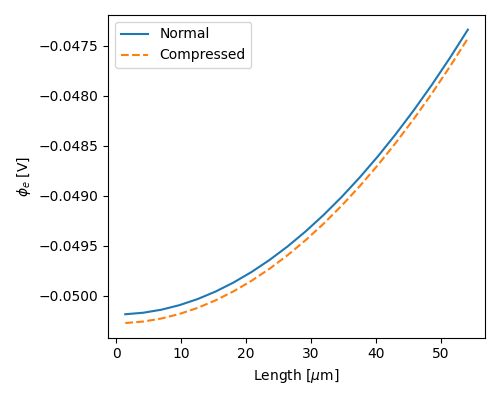

In [42]:
fig = plt.figure(figsize=[5,4])
ax1 = plt.subplot(1,1,1)
ax1.plot(x_n[:,100]*1e6,phi_n_0[:,100])
ax1.plot(x_n[:,100]*1e6,phi_n_1[:,100],'--')
# ax1.axvline(x=55.6,color='k', linestyle='--',linewidth=0.5)
# ax1.axvline(x=55.6+12.5,color='k', linestyle='--',linewidth=0.5)
ax1.set_xlabel('Length [$\mu$m]')
# ax1.set_ylim([-0.2,0])
ax1.set_ylabel('$\phi_e$ [V]')
ax1.legend(['Normal', 'Compressed'])
fig.tight_layout()
fig.savefig(fig_DIR +'lip_pot_'+sim_des+'.png')